In [1]:
# Cell 1: 只加载 overlay，不加载 xmodel
import sys
sys.path.append('/usr/lib/python3/site-packages')
import os, numpy as np
from pynq_dpu import DpuOverlay

WORK_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae'
overlay = DpuOverlay(os.path.join(WORK_DIR, 'dpu.bit'))
print("✅ Overlay OK")

✅ Overlay OK


In [2]:
# Cell 2: 只加载 Encoder，不运行推理
import vart, xir

def get_dpu_subgraph(xmodel_path):
    graph = xir.Graph.deserialize(xmodel_path)
    root = graph.get_root_subgraph()
    children = root.toposort_child_subgraph()
    dpu_subgraphs = [s for s in children
                     if s.has_attr("device") and s.get_attr("device").upper() == "DPU"]
    return graph, dpu_subgraphs[0]

enc_graph, enc_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'encoder_zcu111_700x500_old.xmodel'))
enc_runner = vart.Runner.create_runner(enc_subgraph, "run")
enc_in_tensors  = enc_runner.get_input_tensors()
enc_out_tensors = enc_runner.get_output_tensors()
print("✅ Encoder runner OK")
print(f"   输入 shape: {tuple(enc_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(enc_out_tensors[0].dims)}")

✅ Encoder runner OK
   输入 shape: (1, 500, 700, 3)
   输出 shape: (1, 125, 175, 64)


In [3]:
# Cell 3: 只做 fix_point，不运行推理
def get_fixpoint_scale(tensors):
    scales = []
    for t in tensors:
        try:
            fp = t.get_attr("fix_point")
            scales.append(2 ** (-fp))
            print(f"  {t.name}: fix_point={fp}, scale={2**(-fp):.6f}")
        except:
            scales.append(1.0)
            print(f"  {t.name}: 无fix_point, scale=1.0")
    return scales

enc_in_scales  = get_fixpoint_scale(enc_in_tensors)
enc_out_scales = get_fixpoint_scale(enc_out_tensors)
print("✅ fix_point OK")

  EncoderWrapper__input_0_fix: fix_point=6, scale=0.015625
  EncoderWrapper__EncoderWrapper_Conv2d_pre_quantization_conv__ret_fix: fix_point=6, scale=0.015625
✅ fix_point OK


In [29]:
# # Cell 4: 只做图片预处理
# import cv2
# img_bgr = cv2.imread(os.path.join(WORK_DIR, 'img.png'))
# # img_bgr = cv2.imread(os.path.join(WORK_DIR, 'test2.jpg'))
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# img_small = cv2.resize(img_rgb, (700,500), interpolation=cv2.INTER_LINEAR)
# input_fp32 = (img_small.astype(np.float32)/255.0 - 0.5) / 0.5
# input_fp32 = input_fp32[np.newaxis]
# print(f"✅ 预处理 OK, shape={input_fp32.shape}")

# Cell 4: 只做图片预处理（改用 PIL BILINEAR，和 main.py/transforms.Resize 一致）
from PIL import Image as PILImage
import numpy as np
import os

img_pil    = PILImage.open(os.path.join(WORK_DIR, '0001.png')).convert('RGB')
img_small  = img_pil.resize((700, 500), PILImage.BILINEAR)          # 和 transforms.Resize 一致
img_arr    = np.array(img_small).astype(np.float32)                  # uint8 -> float32
input_fp32 = (img_arr / 255.0 - 0.5) / 0.5                          # 归一化到 [-1,1]
input_fp32 = input_fp32[np.newaxis]                                  # (1,500,700,3)
print(f"✅ 预处理 OK, shape={input_fp32.shape}")

✅ 预处理 OK, shape=(1, 500, 700, 3)


In [30]:
# Cell 5: 只准备 buffer，不执行 execute_async
enc_input_shape  = tuple(enc_in_tensors[0].dims)
enc_output_shape = tuple(enc_out_tensors[0].dims)
enc_in_buf  = [np.empty(enc_input_shape,  dtype=np.int8, order='C')]
enc_out_buf = [np.empty(enc_output_shape, dtype=np.int8, order='C')]
enc_in_buf[0][...] = np.clip(
    np.round(input_fp32 / enc_in_scales[0]), -128, 127
).astype(np.int8)
print(f"✅ Buffer 准备 OK")
print(f"   enc_in_buf  dtype={enc_in_buf[0].dtype}, shape={enc_in_buf[0].shape}")
print(f"   enc_out_buf dtype={enc_out_buf[0].dtype}, shape={enc_out_buf[0].shape}")

✅ Buffer 准备 OK
   enc_in_buf  dtype=int8, shape=(1, 500, 700, 3)
   enc_out_buf dtype=int8, shape=(1, 125, 175, 64)


In [31]:
# Cell 6: 执行encoder，单独执行
print("执行前...")
job_id = enc_runner.execute_async(enc_in_buf, enc_out_buf)
print(f"job_id={job_id}, 等待完成...")
enc_runner.wait(job_id)
print("✅ Encoder 推理完成！")

执行前...
job_id=(1, 0), 等待完成...
✅ Encoder 推理完成！


In [32]:
# Cell 7: 加载 Decoder runner
dec_graph, dec_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'decoder_zcu111_700x500_old.xmodel'))
dec_runner = vart.Runner.create_runner(dec_subgraph, "run")
dec_in_tensors  = dec_runner.get_input_tensors()
dec_out_tensors = dec_runner.get_output_tensors()
dec_in_scales  = get_fixpoint_scale(dec_in_tensors)
dec_out_scales = get_fixpoint_scale(dec_out_tensors)
print("✅ Decoder runner OK")
print(f"   输入 shape: {tuple(dec_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(dec_out_tensors[0].dims)}")

  DecoderWrapper__input_0_fix: fix_point=5, scale=0.031250
  DecoderWrapper__DecoderWrapper_Decoder_decoder__Sequential_inverse_conv_stack__ConvTranspose2d_4__ret_fix: fix_point=7, scale=0.007812
✅ Decoder runner OK
   输入 shape: (1, 125, 175, 64)
   输出 shape: (1, 500, 700, 3)


In [33]:
# Cell 8: 反量化 Encoder 输出 + VectorQuantizer
enc_out_scale = enc_out_scales[0]
z_e = enc_out_buf[0].astype(np.float32) * enc_out_scale
print(f"✅ z_e shape={z_e.shape}, 范围=[{z_e.min():.3f}, {z_e.max():.3f}]")

# 加载 codebook
codebook = np.load(os.path.join(WORK_DIR, 'codebook.npy')).astype(np.float32)
print(f"✅ codebook shape={codebook.shape}")

def vector_quantize(z_e_nhwc, codebook):
    N, H, W, C = z_e_nhwc.shape
    z_flat = z_e_nhwc.reshape(-1, C).astype(np.float32)
    dist = (
        np.sum(z_flat**2, axis=1, keepdims=True)
        + np.sum(codebook**2, axis=1)
        - 2.0 * z_flat @ codebook.T
    )
    indices = np.argmin(dist, axis=1)
    z_q = codebook[indices].reshape(N, H, W, C)
    return z_q, indices.reshape(H, W)

z_q, indices = vector_quantize(z_e, codebook)
print(f"✅ VQ 完成，z_q shape={z_q.shape}")
print(f"   indices 范围: [{indices.min()}, {indices.max()}]")

✅ z_e shape=(1, 125, 175, 64), 范围=[-2.000, 1.984]
✅ codebook shape=(512, 64)
✅ VQ 完成，z_q shape=(1, 125, 175, 64)
   indices 范围: [6, 511]


In [34]:
# # Cell 9: Decoder 推理
# dec_input_shape  = tuple(dec_in_tensors[0].dims)
# dec_output_shape = tuple(dec_out_tensors[0].dims)
# dec_in_buf  = [np.empty(dec_input_shape,  dtype=np.int8, order='C')]
# dec_out_buf = [np.empty(dec_output_shape, dtype=np.int8, order='C')]

# dec_in_buf[0][...] = np.clip(
#     np.round(z_q / dec_in_scales[0]), -128, 127
# ).astype(np.int8)

# print("执行 Decoder 前...")
# job_id = dec_runner.execute_async(dec_in_buf, dec_out_buf)
# print(f"job_id={job_id}, 等待完成...")
# dec_runner.wait(job_id)
# print("✅ Decoder 推理完成！")

# output = dec_out_buf[0].astype(np.float32) * dec_out_scales[0]
# print(f"✅ output shape={output.shape}, 范围=[{output.min():.3f}, {output.max():.3f}]")

# Cell 9 修复版
dec_input_shape  = tuple(dec_in_tensors[0].dims)
dec_output_shape = tuple(dec_out_tensors[0].dims)
dec_in_buf  = [np.empty(dec_input_shape,  dtype=np.int8, order='C')]
dec_out_buf = [np.empty(dec_output_shape, dtype=np.int8, order='C')]

# 原来错误的做法：直接用 dec_in_scales[0] 量化 z_q
# dec_in_buf[0][...] = np.clip(np.round(z_q / dec_in_scales[0]), -128, 127).astype(np.int8)

# 正确做法：先把 z_q clip 到 dec input int8 能表示的范围，再量化
dec_fix   = 5          # fix_point=5，来自 dec_in_tensors fix_point
dec_scale = 2.0 ** (-dec_fix)   # 0.03125

# z_q 的值域由 codebook 决定，检查是否超出范围
z_q_max = np.abs(z_q).max()
int8_max = 127 * dec_scale   # 3.96875
print('z_q abs max:      %.4f' % z_q_max)
print('int8 representable max: %.4f' % int8_max)

# 量化
dec_in_buf[0][...] = np.clip(
    np.round(z_q / dec_scale), -128, 127
).astype(np.int8)

# 反量化验证
z_q_check = dec_in_buf[0].astype(np.float32) * dec_scale
print('z_q after quant/dequant range: [%.4f, %.4f]' % (z_q_check.min(), z_q_check.max()))
print('z_q original range:            [%.4f, %.4f]' % (z_q.min(), z_q.max()))
mse = np.mean((z_q - z_q_check) ** 2)
print('re-quant MSE: %.8f' % mse)

print('执行 Decoder 前...')
job_id = dec_runner.execute_async(dec_in_buf, dec_out_buf)
print('job_id=%s, 等待完成...' % str(job_id))
dec_runner.wait(job_id)
print('✅ Decoder 推理完成！')

output = dec_out_buf[0].astype(np.float32) * dec_out_scales[0]
print('output range: [%.4f, %.4f]' % (output.min(), output.max()))

z_q abs max:      1.8365
int8 representable max: 3.9688
z_q after quant/dequant range: [-1.8125, 1.8438]
z_q original range:            [-1.8029, 1.8365]
re-quant MSE: 0.00008103
执行 Decoder 前...
job_id=(1, 0), 等待完成...
✅ Decoder 推理完成！
output range: [-1.0000, 0.9297]


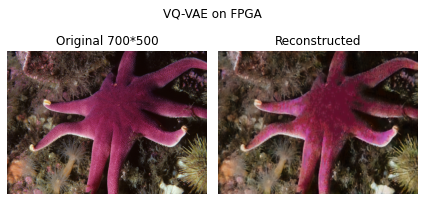

✅ 完成！结果保存至 result.png


In [35]:
# Cell 10: 显示结果
import matplotlib.pyplot as plt

original  = cv2.resize(
    cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'0001.png')), cv2.COLOR_BGR2RGB),
    (700,500))
    # cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'test2.jpg')), cv2.COLOR_BGR2RGB),
    # (700,500))

recon = output[0] * 0.5 + 0.5
recon = np.clip(recon, 0.0, 1.0)
recon = (recon * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original);  axes[0].set_title('Original 700*500'); axes[0].axis('off')
axes[1].imshow(recon);     axes[1].set_title('Reconstructed');  axes[1].axis('off')
plt.suptitle('VQ-VAE on FPGA', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result.png'), dpi=300)
plt.show()
print("✅ 完成！结果保存至 result.png")


图像质量评估（原图 vs 重建图）
   SSIM : 0.7919
   PSNR : 25.68 dB


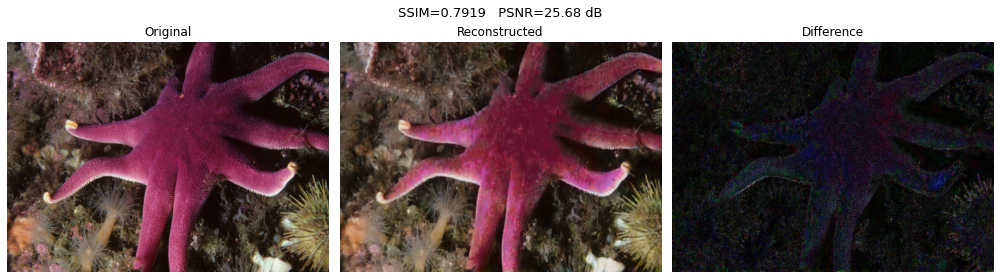

✅ 保存至 result_metrics.png


In [36]:
# Cell 11: 计算 SSIM 和 PSNR
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim_func

WORK_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae'

# original：直接从送进 encoder 的 input_fp32 反归一化，和 main.py 完全一致
# input_fp32 shape=(1,500,700,3)，值域 [-1,1]
original = (input_fp32[0] * 0.5 + 0.5).clip(0.0, 1.0).astype(np.float32)  # [0,1]

# recon：DPU decoder 输出反归一化
# output shape=(1,500,700,3)，值域约 [-1,1]
recon = (output[0] * 0.5 + 0.5).clip(0.0, 1.0).astype(np.float32)         # [0,1]

ssim_val = ssim_func(original, recon, multichannel=True, data_range=2.0)
mse      = np.mean((original - recon) ** 2)
psnr_val = 20 * np.log10(1.0 / np.sqrt(mse + 1e-8))

print(f"\n图像质量评估（原图 vs 重建图）")
print(f"   SSIM : {ssim_val:.4f}")
print(f"   PSNR : {psnr_val:.2f} dB")

diff      = np.abs(original - recon)
diff_norm = (diff / (diff.max() + 1e-8) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(original);               axes[0].set_title('Original');      axes[0].axis('off')
axes[1].imshow(recon);                  axes[1].set_title('Reconstructed'); axes[1].axis('off')
axes[2].imshow(diff_norm, cmap='hot');  axes[2].set_title('Difference');    axes[2].axis('off')
plt.suptitle(f'SSIM={ssim_val:.4f}   PSNR={psnr_val:.2f} dB', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result_metrics.png'), dpi=300)
plt.show()
print("✅ 保存至 result_metrics.png")